<a href="https://colab.research.google.com/github/Paddylep/Robotic-Health-Monitoring-System/blob/main/RNN%20Training/Final_Project_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from google.colab import drive # importing your gdrive
drive.mount('/content/gdrive') # mounting your gdrive
import matplotlib.pyplot as plt
import torch.utils.data as data
from sklearn.metrics import r2_score, mean_absolute_error

Mounted at /content/gdrive


In [ ]:
column_names = ['timestamp', 'x', 'y', 'z']
dataset = pd.read_csv("/content/gdrive/MyDrive/logging.csv", header=None, names=column_names)
display(dataset.head())
features = dataset[['x', 'y', 'z']].values

,timestamp,x,y,z
0,17:34:14,0.0030,0.0027,0.2521
1,NaN,NaN,NaN,NaN
2,17:34:14,0.0028,0.0024,0.2519
3,NaN,NaN,NaN,NaN
4,17:34:14,0.0029,0.0022,0.2525


In [ ]:
class RegressionRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        _, (h_n, _) = self.rnn(x)
        out = self.fc(h_n[-1])
        return out

In [ ]:
sequence_length = 100

X_sequences = []
y_targets = []

for i in range(len(features) - sequence_length + 1):
    X_sequences.append(features[i : i + sequence_length])
    y_targets.append(features[i + sequence_length - 1])

X = torch.tensor(np.array(X_sequences), dtype=torch.float32)
y = torch.tensor(np.array(y_targets), dtype=torch.float32)

train_size = int(0.6 * len(X))
test_size = int(0.2 * len(X))
valid_size = len(X) - train_size - test_size

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size : train_size + test_size], y[train_size : train_size + test_size]
X_valid, y_valid = X[train_size + test_size :], y[train_size + test_size :]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: torch.Size([271984, 100, 3])
y_train shape: torch.Size([271984, 3])
X_test shape: torch.Size([90661, 100, 3])
y_test shape: torch.Size([90661, 3])
X_valid shape: torch.Size([90663, 100, 3])
y_valid shape: torch.Size([90663, 3])


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

features_df = pd.DataFrame(features)

outlier_threshold_x = 100.0
features_df.loc[features_df[0] > outlier_threshold_x, 0] = np.nan

features_cleaned = features_df.interpolate(method='linear', limit_direction='both')
features_cleaned = features_cleaned.fillna(method='bfill').fillna(method='ffill').values

features_scaled = scaler.fit_transform(features_cleaned)

X_sequences_scaled = []
y_targets_final = []

for i in range(len(features_scaled) - sequence_length + 1):
    X_sequences_scaled.append(features_scaled[i : i + sequence_length])
    y_targets_final.append(features_scaled[i + sequence_length - 1])

X = torch.tensor(np.array(X_sequences_scaled), dtype=torch.float32)
y = torch.tensor(np.array(y_targets_final), dtype=torch.float32)

train_size = int(0.6 * len(X))
test_size = int(0.2 * len(X))
valid_size = len(X) - train_size - test_size

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size : train_size + test_size], y[train_size : train_size + test_size]
X_valid, y_valid = X[train_size + test_size :], y[train_size + test_size :]

print(f"Scaled X_train shape: {X_train.shape}")
print(f"Scaled y_train shape: {y_train.shape}")
print(f"Scaled X_test shape: {X_test.shape}")
print(f"Scaled y_test shape: {y_test.shape}")
print(f"Scaled X_valid shape: {X_valid.shape}")
print(f"Scaled y_valid shape: {y_valid.shape}")

/tmp/ipykernel_683/1482449463.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features_cleaned = features_cleaned.fillna(method='bfill').fillna(method='ffill').values


Scaled X_train shape: torch.Size([271984, 100, 3])
Scaled y_train shape: torch.Size([271984, 3])
Scaled X_test shape: torch.Size([90661, 100, 3])
Scaled y_test shape: torch.Size([90661, 3])
Scaled X_valid shape: torch.Size([90663, 100, 3])
Scaled y_valid shape: torch.Size([90663, 3])


In [ ]:
model = RegressionRNN(input_dim=3, hidden_dim=10, num_layers=4, dropout=0.3)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_dataset = data.TensorDataset(X_train, y_train)
test_dataset = data.TensorDataset(X_test, y_test)
valid_dataset = data.TensorDataset(X_valid, y_valid)

batch_size = 32
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
valid_loader = data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")
print(f"Number of validation batches: {len(valid_loader)}")

Number of training batches: 8500
Number of testing batches: 2834
Number of validation batches: 2834


In [ ]:
num_epochs = 100

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    with torch.no_grad():
        total_test_loss = 0
        for batch_X_test, batch_y_test in test_loader:
            test_predictions = model(batch_X_test)
            test_loss = criterion(test_predictions, batch_y_test)
            total_test_loss += test_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_test_loss = total_test_loss / len(test_loader)
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

Epoch 1/100, Train Loss: 0.0019, Test Loss: 0.0006
Epoch 2/100, Train Loss: 0.0007, Test Loss: 0.0002
Epoch 3/100, Train Loss: 0.0006, Test Loss: 0.0002
Epoch 4/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 5/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 6/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 7/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 8/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 9/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 10/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 11/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 12/100, Train Loss: 0.0006, Test Loss: 0.0001
Epoch 13/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 14/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 15/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 16/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 17/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 18/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 19/100, Train Loss: 0.0005, Test Loss: 0.0001
Epoch 20/100, Train L

In [ ]:
model.eval()

with torch.no_grad():
    scaled_test_predictions = model(X_test)

    original_test_predictions = scaler.inverse_transform(scaled_test_predictions.cpu().numpy())
    original_y_test = scaler.inverse_transform(y_test.cpu().numpy())

    mse_original = nn.MSELoss()(torch.tensor(original_test_predictions), torch.tensor(original_y_test)).item()

    r2_original = r2_score(original_y_test, original_test_predictions)

    mae_original = mean_absolute_error(original_y_test, original_test_predictions)

    residuals = original_y_test - original_test_predictions
    avaerage_residuals = np.mean(np.abs(residuals))

    print(f"\n--- Test Set Metrics (Original Scale) ---")
    print(f"Test MSE: {mse_original:.8f}")
    print(f"Test MAE: {mae_original:.4f}")
    print(f"Test R-squared: {r2_original:.4f}")
    print(f"Test RE: {avaerage_residuals:.4f}")

KeyboardInterrupt: 


--- Validation Set Metrics (Original Scale) ---
Validation MSE: 0.0000
Validation MAE: 0.0029
Validation R-squared: 0.9571
Validation RE: 0.0029


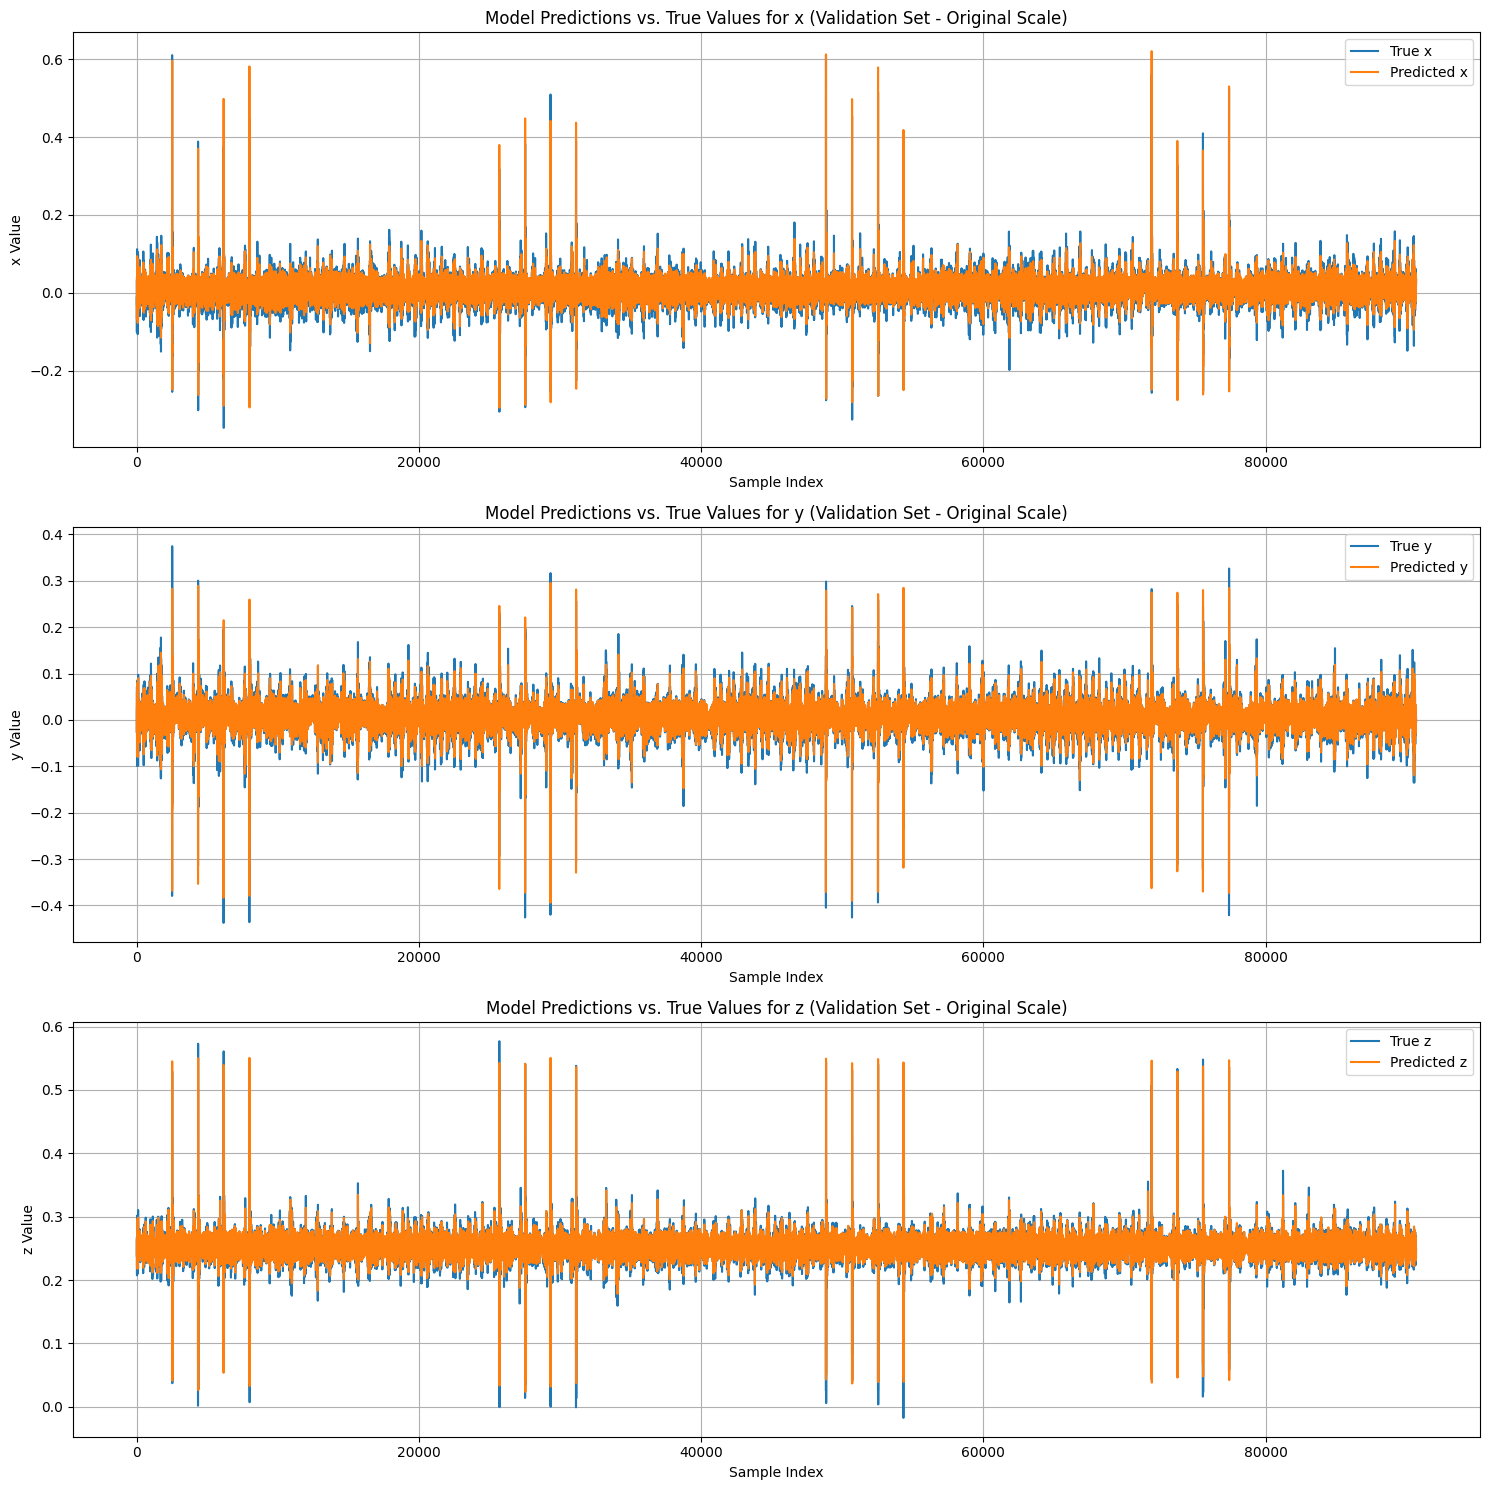

In [ ]:
model.eval()

with torch.no_grad():
    scaled_valid_predictions = model(X_valid)

    original_valid_predictions = scaler.inverse_transform(scaled_valid_predictions.cpu().numpy())
    original_y_valid = scaler.inverse_transform(y_valid.cpu().numpy())

    mse_valid_original = nn.MSELoss()(torch.tensor(original_valid_predictions), torch.tensor(original_y_valid)).item()

    r2_valid_original = r2_score(original_y_valid, original_valid_predictions)

    mae_valid_original = mean_absolute_error(original_y_valid, original_valid_predictions)

    residuals_valid = original_y_valid - original_valid_predictions
    average_residuals_valid = np.mean(np.abs(residuals_valid))

    print(f"\n--- Validation Set Metrics (Original Scale) ---")
    print(f"Validation MSE: {mse_valid_original:.4f}")
    print(f"Validation MAE: {mae_valid_original:.4f}")
    print(f"Validation R-squared: {r2_valid_original:.4f}")
    print(f"Validation RE: {average_residuals_valid:.4f}")

num_dimensions = original_y_valid.shape[1]
dimension_labels = ['x', 'y', 'z']

plt.figure(figsize=(15, 5 * num_dimensions))

for i in range(num_dimensions):
    plt.subplot(num_dimensions, 1, i + 1)
    plt.plot(original_y_valid[:, i], label=f'True {dimension_labels[i]}')
    plt.plot(original_valid_predictions[:, i], label=f'Predicted {dimension_labels[i]}')
    plt.title(f'Model Predictions vs. True Values for {dimension_labels[i]} (Validation Set - Original Scale)')
    plt.xlabel('Sample Index')
    plt.ylabel(f'{dimension_labels[i]} Value')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

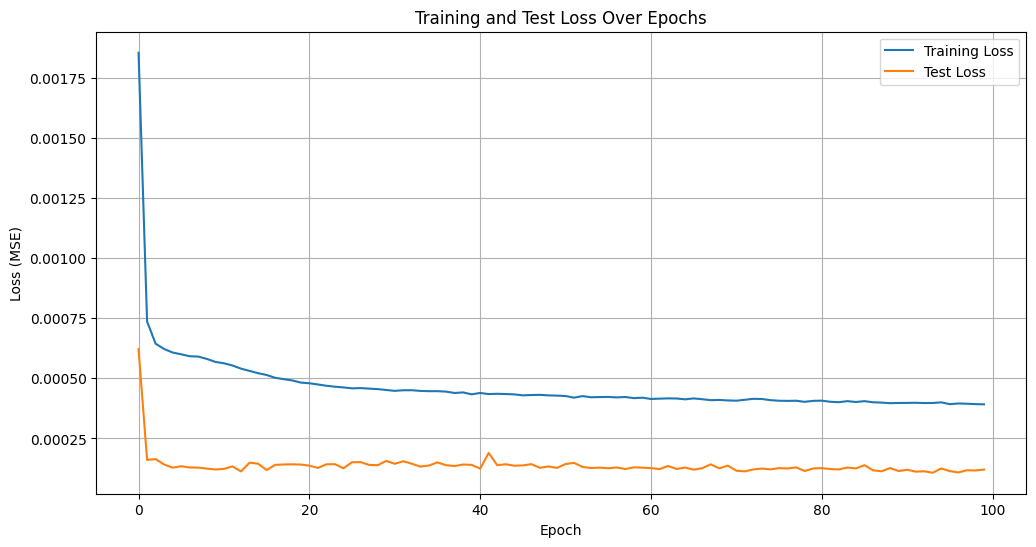

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

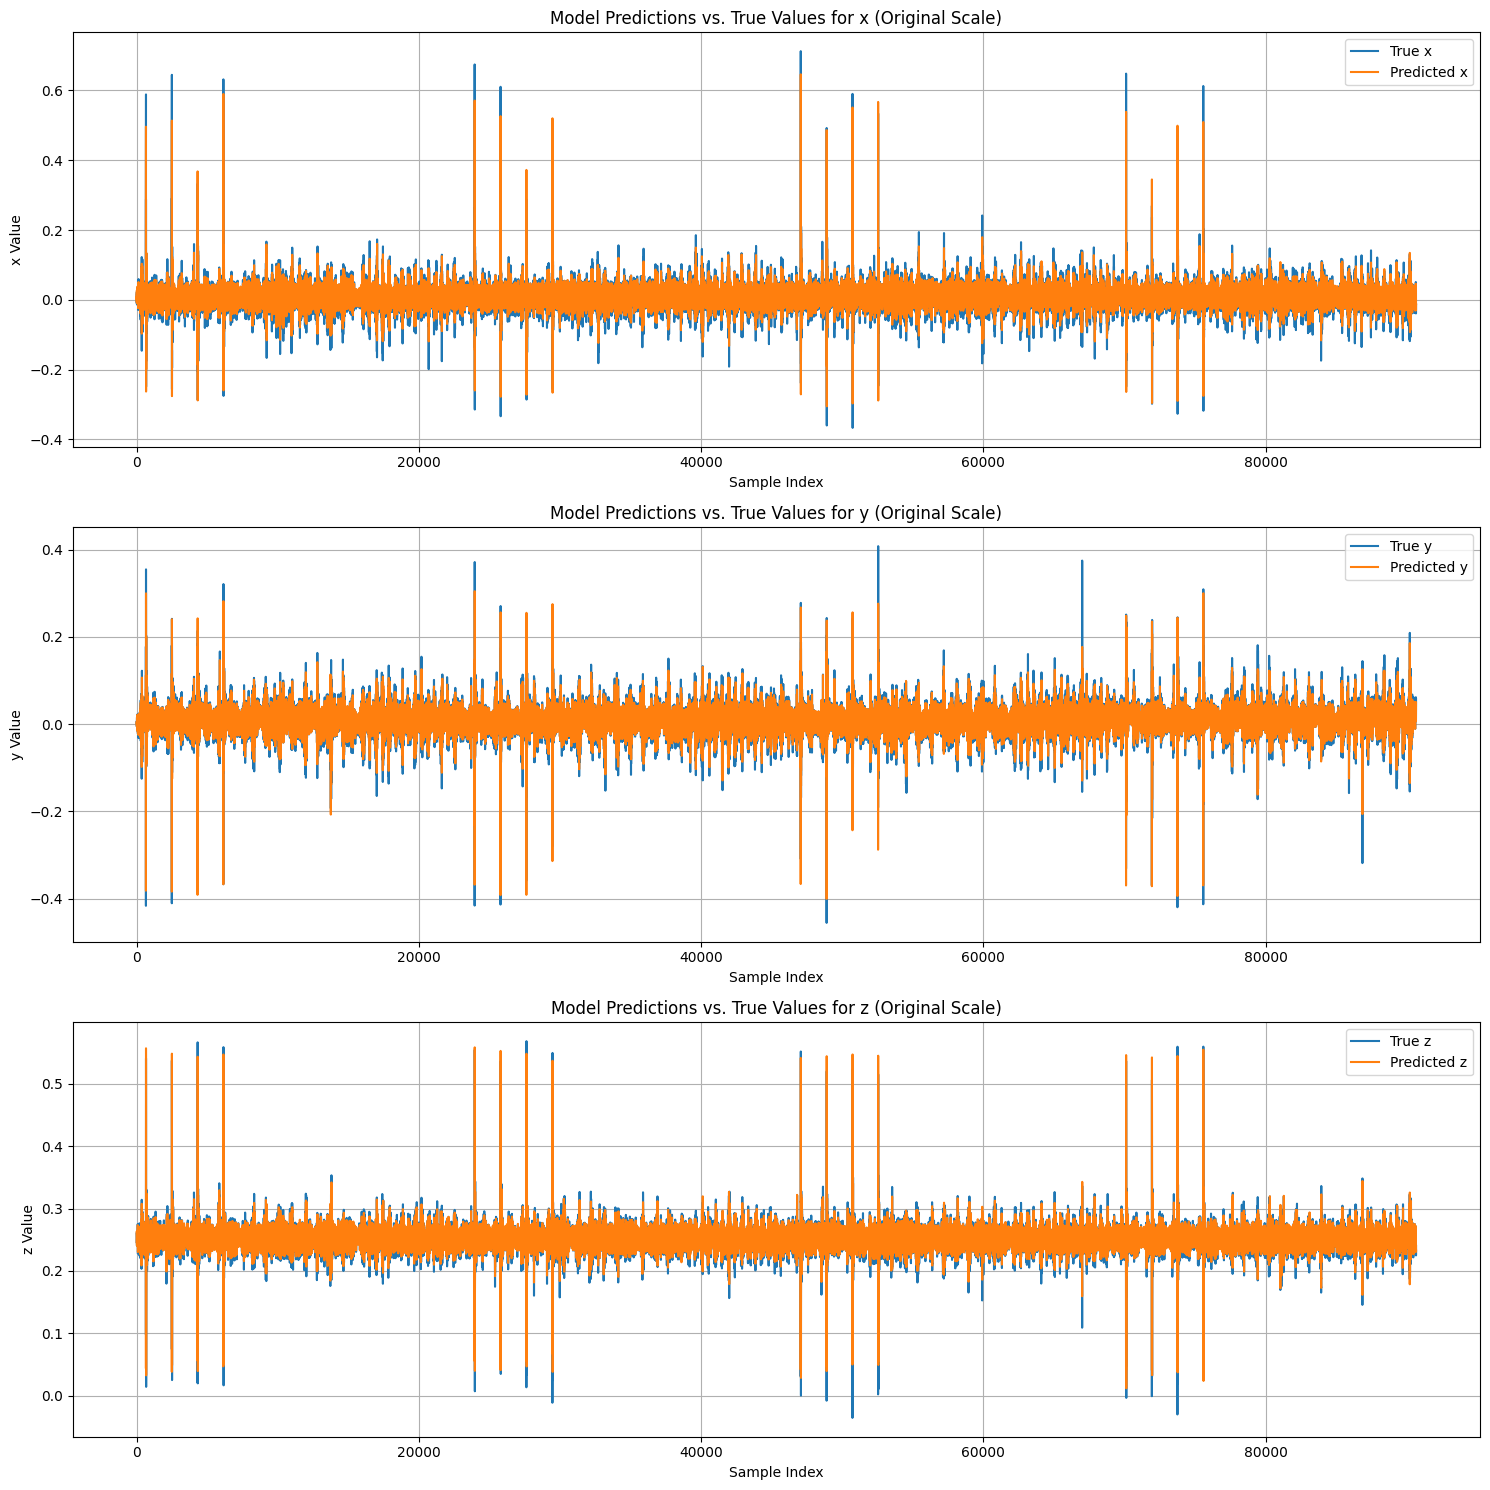

In [ ]:
num_dimensions = original_y_test.shape[1]
dimension_labels = ['x', 'y', 'z']

plt.figure(figsize=(15, 5 * num_dimensions))

for i in range(num_dimensions):
    plt.subplot(num_dimensions, 1, i + 1)
    plt.plot(original_y_test[:, i], label=f'True {dimension_labels[i]}')
    plt.plot(original_test_predictions[:, i], label=f'Predicted {dimension_labels[i]}')
    plt.title(f'Model Predictions vs. True Values for {dimension_labels[i]} (Original Scale)')
    plt.xlabel('Sample Index')
    plt.ylabel(f'{dimension_labels[i]} Value')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def save_model_as_c_header(model, filename='regression_rnn_model.h'):
    """
    Saves the PyTorch model's state dictionary parameters into a C++ header file.
    Each parameter (weight/bias) is formatted as a `const float[]` array.
    """
    state_dict = model.state_dict()
    with open(filename, 'w') as f:
        f.write("#ifndef REGRESSION_RNN_MODEL_H\n")
        f.write("#define REGRESSION_RNN_MODEL_H\n\n")
        f.write("#include <vector>\n\n")

        for name, param in state_dict.items():
            c_name = name.replace('.', '_').replace('-', '_')
            param_flat = param.cpu().numpy().flatten()

            formatted_values = [f"{val:.8f}f" for val in param_flat]
            values_str = ""
            for i in range(0, len(formatted_values), 10):
                values_str += ", ".join(formatted_values[i:i+10])
                if i + 10 < len(formatted_values):
                    values_str += ",\n    "

            f.write(f"const float {c_name}[] = {{\n    {values_str}\n}};")

            dim_values_str = ", ".join(map(str, param.shape))
            f.write(f"\nconst int {c_name}_dims[] = {{{dim_values_str}}};")
            f.write(f"\nconst int {c_name}_num_dims = {len(param.shape)};\n\n")

        f.write("#endif // REGRESSION_RNN_MODEL_H\n")

    print(f"Model parameters saved successfully to {filename}")

save_model_as_c_header(model, 'regression_rnn_model.h')